# Supply Chain Performance & Inventory Optimization - 7,991 Orders

**The brief:** half of all orders miss the 5-day delivery target and $41M of revenue is
exposed. Leadership wants to know whether to invest in one bad warehouse, or the network.

This notebook is the exploratory half of the project. The business answers are summarised
in [README.md](README.md) as **Q1-Q8**, and the production queries live in
`sql_queries/02_sales_analysis.sql`. Each section below is labelled with the README
Q-number it supports.

**The headline finding, up front:** the brief's premise is wrong. It is not one
warehouse - only **0.08% of delivery-time variance sits between warehouses**. The
analysis below shows how that conclusion was reached.

---

## Section 0 - Setup

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---

## Section 1 - Load & Profile

**Question before any analysis: can I trust this data?** `info()` and `describe()` come
first so every number later is traceable to a known population, with the dtypes and
ranges visible rather than assumed.

In [ ]:
df = pd.read_csv("data/Supplychain_rawData.csv")
df.head()

,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,_StoreID,_ProductID,Order Quantity,Discount Applied,Unit Cost,Unit Price
0,SO - 000101,In-Store,WARE-UHY1004,31/12/17,31/5/18,14/6/18,19/6/18,USD,6,15,259,12,5,0.08,"$1,001.18","$1,963.10"
1,SO - 000102,Online,WARE-NMK1003,31/12/17,31/5/18,22/6/18,2/7/2018,USD,14,20,196,27,3,0.08,"$3,348.66","$3,939.60"
2,SO - 000103,Distributor,WARE-UHY1004,31/12/17,31/5/18,21/6/18,1/7/2018,USD,21,16,213,16,1,0.05,$781.22,"$1,775.50"
3,SO - 000104,Wholesale,WARE-NMK1003,31/12/17,31/5/18,2/6/2018,7/6/2018,USD,28,48,107,23,8,0.08,"$1,464.69","$2,324.90"
4,SO - 000105,Distributor,WARE-NMK1003,10/4/2018,31/5/18,16/6/18,26/6/18,USD,22,49,111,26,8,0.10,"$1,476.14","$1,822.40"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7991 entries, 0 to 7990
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderNumber       7991 non-null   object 
 1   Sales Channel     7991 non-null   object 
 2   WarehouseCode     7991 non-null   object 
 3   ProcuredDate      7991 non-null   object 
 4   OrderDate         7991 non-null   object 
 5   ShipDate          7991 non-null   object 
 6   DeliveryDate      7991 non-null   object 
 7   CurrencyCode      7991 non-null   object 
 8   _SalesTeamID      7991 non-null   int64  
 9   _CustomerID       7991 non-null   int64  
 10  _StoreID          7991 non-null   int64  
 11  _ProductID        7991 non-null   int64  
 12  Order Quantity    7991 non-null   int64  
 13  Discount Applied  7991 non-null   float64
 14  Unit Cost         7991 non-null   object 
 15  Unit Price        7991 non-null   object 
dtypes: float64(1), int64(5), object(10)
memory

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
_SalesTeamID,7991.0,14.384307,7.986086,1.00,8.00,14.00,21.00,28.0
_CustomerID,7991.0,25.457014,14.414883,1.00,13.00,25.00,38.00,50.0
_StoreID,7991.0,183.850081,105.903946,1.00,91.00,183.00,276.00,367.0
_ProductID,7991.0,23.771743,13.526545,1.00,12.00,24.00,36.00,47.0
Order Quantity,7991.0,4.525341,2.312631,1.00,3.00,5.00,7.00,8.0
Discount Applied,7991.0,0.115649,0.085018,0.05,0.05,0.08,0.15,0.4


---

## Section 2 - Cleaning

Each step below prints rows before and after. Dropping rows without reporting how many is
how an analysis quietly loses population and nobody notices - so the impact is made
measurable rather than decorative.

In [ ]:
# Handle missing values (measure the impact so the step is honest, not decorative)
rows_before = len(df)
df.dropna(inplace=True)
rows_after = len(df)
print(f"Rows before dropna: {rows_before:,}  |  after: {rows_after:,}  |  dropped: {rows_before - rows_after:,}")
print("Note: the raw file is already complete (0 rows dropped); dropna is kept as a defensive safeguard.")

In [ ]:
# Remove duplicates (report how many were actually removed)
rows_before = len(df)
df.drop_duplicates(inplace=True)
rows_after = len(df)
print(f"Rows before dedup: {rows_before:,}  |  after: {rows_after:,}  |  removed: {rows_before - rows_after:,}")
print("Note: no duplicate orders exist in this dataset (0 removed); the step is a reusable integrity check.")

In [ ]:
# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")


In [ ]:
# Clean currency columns
df['Unit_Price'] = df['Unit_Price'].replace(r'[\$,]', '', regex=True).astype(float)
df['Unit_Cost'] = df['Unit_Cost'].replace(r'[\$,]', '', regex=True).astype(float)

In [ ]:

# Convert dates
df['OrderDate'] = pd.to_datetime(df['OrderDate'], dayfirst=True)
df['ShipDate'] = pd.to_datetime(df['ShipDate'], dayfirst=True)
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'], dayfirst=True)
df['ProcuredDate'] = pd.to_datetime(df['ProcuredDate'], dayfirst=True)

/tmp/ipykernel_802/721366794.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['OrderDate'] = pd.to_datetime(df['OrderDate'], dayfirst=True)
/tmp/ipykernel_802/721366794.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ShipDate'] = pd.to_datetime(df['ShipDate'], dayfirst=True)
/tmp/ipykernel_802/721366794.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'], dayfirst=True)
/tmp/ipykernel_802/721366794.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `date

---

## Section 3 - Feature Engineering

The raw log has dates and prices but no *metrics*. Everything the business actually asks
about has to be derived here:

- `delivery_days` - the column the entire fulfilment question rests on
- `revenue`, `total_cost`, `profit`, `profit_margin` - the P&L view
- `on_time` - the 5-day SLA flag that turns "how slow" into "did we meet the promise"

Note `revenue = Order_Quantity x Unit_Price`, which is **gross** (pre-discount). The
Power BI dashboard shows $73.04M net; this notebook and the README quote $82.69M gross.
Both are correct - the $9.66M gap is exactly the discount given. It is documented in the
README so the two figures never look like an error.

In [ ]:
# Feature engineering
df['delivery_days'] = (df['DeliveryDate'] - df['ShipDate']).dt.days
df['revenue'] = df['Order_Quantity'] * df['Unit_Price']
df['total_cost'] = df['Order_Quantity'] * df['Unit_Cost']
df['profit'] = df['revenue'] - df['total_cost']
df['order_to_ship_days'] = (df['ShipDate'] - df['OrderDate']).dt.days
df['procure_to_order_days'] = (df['OrderDate'] - df['ProcuredDate']).dt.days
df['profit_margin'] = (df['profit'] / df['revenue']) * 100



---

## Section 4 - First-Pass Business Insights

### Q1 - which channel makes us the most money?

*Metric: revenue by sales channel.*

**Takeaway:** In-Store leads on volume ($34.0M / $12.7M profit), but **Wholesale has the
best margin at 38.13%** on the smallest base ($9.2M). Margins across all channels sit in
a tight 36.94%-38.13% band, so no channel is discounting itself into trouble.

The cell below also names the "fastest warehouse" - **that number is a trap**, and
Section 5 explains why.

In [ ]:
# Bussiness Insights

# 1. Top revenue channel
top_channel = df.groupby('Sales_Channel')['revenue'].sum().idxmax()
print(f"Top Revenue Channel: {top_channel}")

# 2. Fastest warehouse
fastest_wh = df.groupby('WarehouseCode')['delivery_days'].mean().idxmin()
print(f"Fastest Warehouse: {fastest_wh}")

# 3. Slowest warehouse
slowest_wh = df.groupby('WarehouseCode')['delivery_days'].mean().idxmax()
print(f"Slowest Warehouse: {slowest_wh}")

# 4. High discount impact
high_discount = df[df['Discount_Applied'] > 0.2]['revenue'].mean()
low_discount = df[df['Discount_Applied'] <= 0.2]['revenue'].mean()

print(f"Avg Revenue with High Discount: {round(high_discount,2)}")
print(f"Avg Revenue with Low Discount: {round(low_discount,2)}")

# 5. Delivery risk insight
delayed_orders = df[df['delivery_days'] > df['delivery_days'].mean()].shape[0]
print(f"Orders with above-average delivery time: {delayed_orders}")

Top Revenue Channel: In-Store
Fastest Warehouse: WARE-MKL1006
Slowest Warehouse: WARE-XYS1001
Avg Revenue with High Discount: 11057.85
Avg Revenue with Low Discount: 10283.61
Orders with above-average delivery time: 3953


### KPI baseline

*Metric: revenue, profit and delivery-day aggregates plus channel and warehouse splits.*

**Takeaway:** $82.69M gross revenue, $30.87M profit at a **37.4% margin**, average
delivery **5.5 days** across 7,991 orders. Only **50.5%** hit the 5-day target -
**3,953 late orders**.

That last number is the whole brief. Everything after this section is about finding out
what causes it.

In [ ]:
# KPI Analysis
print("\n===== KPI =====")
print(df[['revenue','profit','delivery_days']].agg(['sum','mean','min','max']))

print("\nSales by Channel:")
print(df.groupby('Sales_Channel')['revenue'].sum())

print("\nDelivery by Warehouse:")
print(df.groupby('WarehouseCode')['delivery_days'].mean())

print(f"Average Profit Margin: {df['profit_margin'].mean():.2f}%")

print(df[['revenue','profit','profit_margin','delivery_days']]
      .agg(['sum','mean','min','max']))




===== KPI =====
           revenue        profit  delivery_days
sum   8.269273e+07  3.087466e+07   43982.000000
mean  1.034823e+04  3.863679e+03       5.503942
min   1.675000e+02  2.512000e+01       1.000000
max   5.231360e+04  3.090576e+04      10.000000

Sales by Channel:
Sales_Channel
Distributor    14809907.8
In-Store       34040113.8
Online         24629756.1
Wholesale       9212948.9
Name: revenue, dtype: float64

Delivery by Warehouse:
WarehouseCode
WARE-MKL1006    5.348891
WARE-NBV1002    5.377713
WARE-NMK1003    5.509381
WARE-PUJ1005    5.584425
WARE-UHY1004    5.496443
WARE-XYS1001    5.585106
Name: delivery_days, dtype: float64
Average Profit Margin: 37.37%
           revenue        profit  profit_margin  delivery_days
sum   8.269273e+07  3.087466e+07  298618.584046   43982.000000
mean  1.034823e+04  3.863679e+03      37.369364       5.503942
min   1.675000e+02  2.512000e+01      14.997015       1.000000
max   5.231360e+04  3.090576e+04      60.000000      10.000000


---

## Section 5 - Visual Analysis

### Q1 (visual) - revenue by channel

**Takeaway:** confirms In-Store as the volume leader. Revenue alone does not decide
strategy though - Wholesale's higher margin is what makes it the growth target.

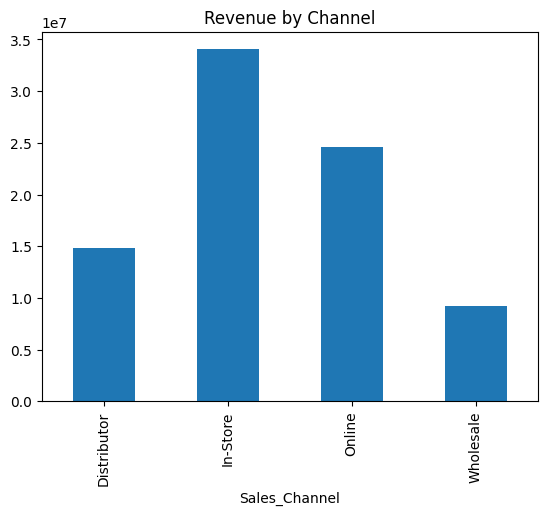

In [ ]:
# Revenue by channel
df.groupby('Sales_Channel')['revenue'].sum().plot(
  kind='bar',
  title="Revenue by Channel"
)
plt.show()

### Q2 - which warehouse is slowest?

*Metric: average delivery days by warehouse.*

**Takeaway - and this is the important one:** the bars are almost identical. Average
delivery ranges only **5.35 to 5.59 days** across all six warehouses. A 0.24-day spread.

A chart that shows *no* difference is still a finding. It is the first evidence that the
brief's premise - "one warehouse is causing this" - does not hold. Section 6 of the SQL
proves it properly: standard deviation is **2.82-2.88 days at every single site**, and
only **0.08%** of delivery-time variance is between warehouses.

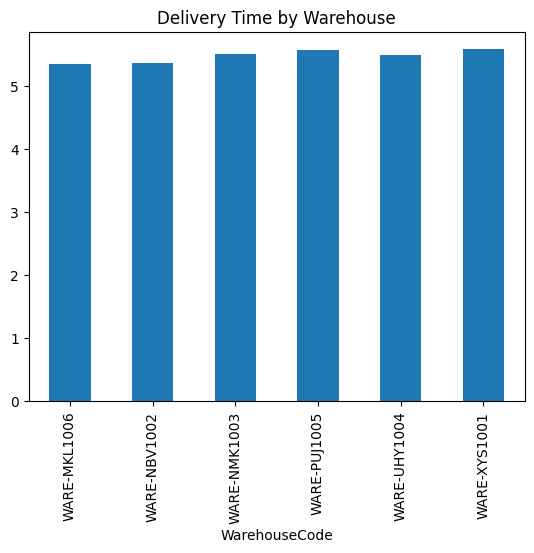

In [ ]:

# Delivery by warehouse
df.groupby('WarehouseCode')['delivery_days'].mean().plot(
    kind='bar',
    title="Delivery Time by Warehouse"
)
plt.show()

### Q5 - are we losing money on any orders?

*Metric: distribution of order-level profit.*

**Takeaway:** the distribution sits entirely above zero. **Zero loss-making orders**
across all 7,991 - the worst SKU still holds a 34.44% margin. Pricing floors are working.

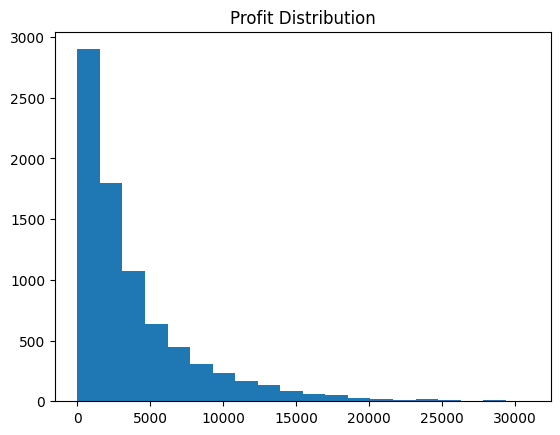

In [ ]:
# Profit distribution
plt.hist(df['profit'], bins=20)
plt.title("Profit Distribution")
plt.show()


### Q8 - is the business still growing?

*Metric: monthly revenue and profit trend.*

**Takeaway:** growth **stalled**. $19.29M (2018, partial year) to $31.53M (2019), then
$31.86M in 2020 - just **+1.0%**. Margin held but the top line stopped moving.

This was not in the original brief. Flagging it anyway is the difference between
answering a question and being useful.

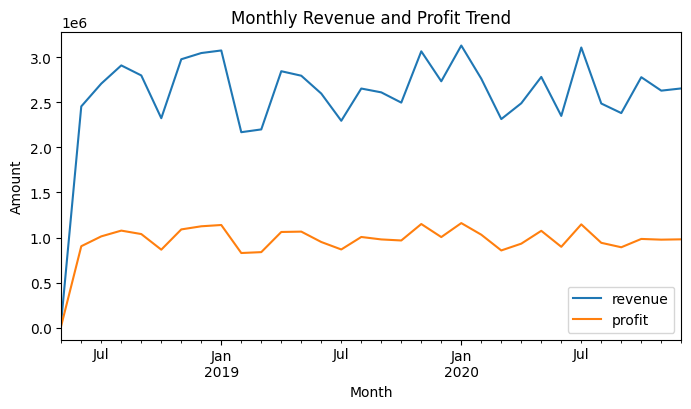

In [ ]:
# Monthly trend
monthly = df.groupby(
    df['OrderDate'].dt.to_period('M')
).agg({'revenue':'sum',
       'profit':'sum'
})

monthly.plot(figsize=(8,4))
plt.title("Monthly Revenue and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

### Q6 - is our margin eroding?

*Metric: profit-margin distribution.*

**Takeaway:** tight and consistent around **37.4%**. The SQL confirms it over time
(section 7, `LAG()`): 32 months of oscillation around 37% with no downward drift. The
worst month, 2020-10 at 35.44%, recovered the following month.

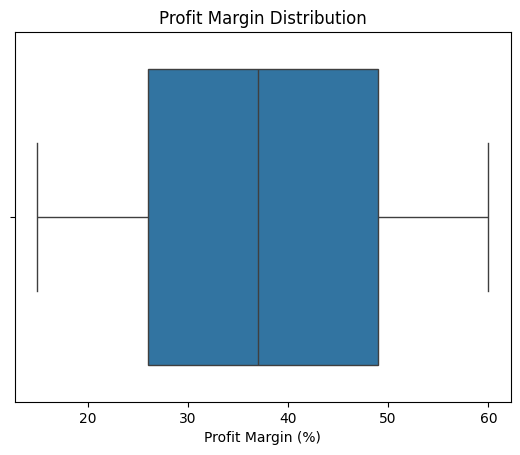

In [ ]:
# Profit Margin Distribution
sns.boxplot(x=df['profit_margin'])

plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")

plt.show()

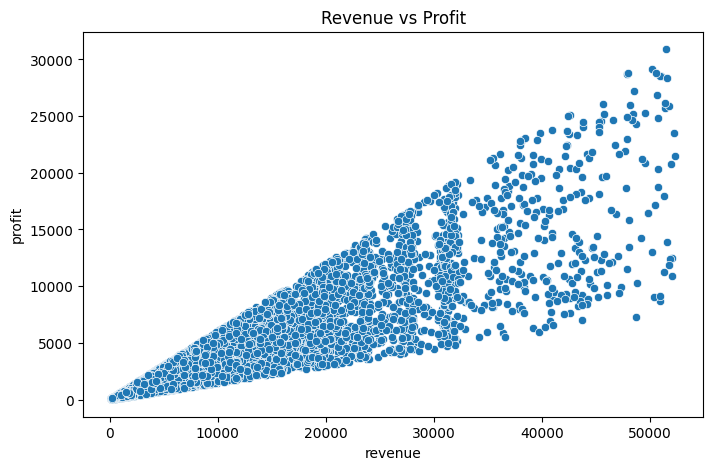

In [ ]:
# Revenue VS Profit Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='revenue',
    y='profit'
)
plt.title("Revenue vs Profit")
plt.show()

### The confounder check

*Metric: correlation matrix across quantities, prices, discounts and delivery.*

**Takeaway - two findings the SQL confirms independently:**

- `Discount_Applied` vs `profit` is **+0.018**. Discounting has no measurable margin
  cost, which is **Q4**: orders at 20%+ discount realise a *higher* 38.28% margin than
  the 5-10% band, because discounts land on already-high-margin products. A blanket
  discount cap would cost revenue and protect nothing.
- `delivery_days` vs `revenue` is **0.0003**. Lateness is unrelated to order value, so it
  is not concentrated in the big orders - further evidence the problem is systemic rather
  than targeted at a segment.

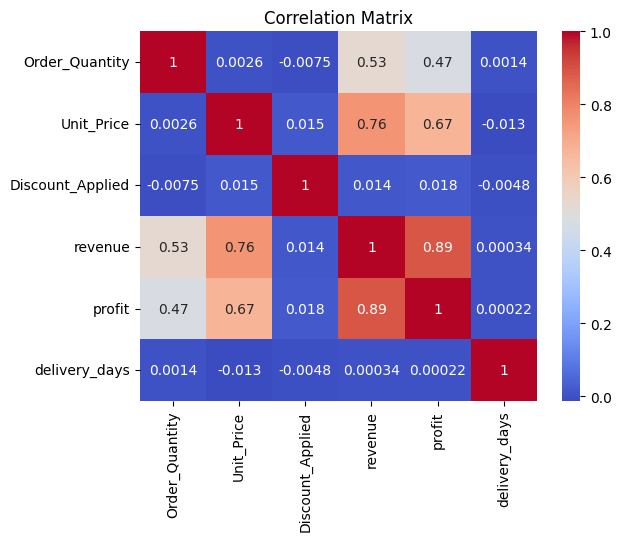

In [ ]:
# heatmap
corr = df[['Order_Quantity','Unit_Price','Discount_Applied','revenue','profit','delivery_days']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

---

## Section 6 - Executive Summary & Handoff

In [ ]:
# Executive summary

print(f"Total revenue: {df['revenue'].sum():,.0f}")
print(f"Total profit: {df['profit'].sum():,.0f}")
print(f"Average delivery days: {df['delivery_days'].mean():.2f}")
print("Top performing channel:", df.groupby('Sales_Channel')['revenue'].sum().idxmax())
print("Fastest warehouse:", df.groupby('WarehouseCode')['delivery_days'].mean().idxmin())
print(f"Average Profit Margin: {df['profit_margin'].mean():.2f}%")

Total revenue: 82,692,727
Total profit: 30,874,658
Average delivery days: 5.50
Top performing channel: In-Store
Fastest warehouse: WARE-MKL1006
Average Profit Margin: 37.37%


In [ ]:
# Export cleaned data for Excel / Power BI
# NOTE: exports to a notebook-local copy so it never overwrites
# the authoritative Cleaned_Supplychain_Data.csv produced by src/data_cleaning.py
df.to_csv("data/Supplychain_NotebookCleaned.csv", index=False)
print("Exported to data/Supplychain_NotebookCleaned.csv (notebook-local copy)")


---

## Business Recommendations

These follow from the findings above, including the ones that say *do nothing*.

1. **Attack the systemic delivery gap, not a single hub.** With only 0.08% of
   delivery-time variance between warehouses, a per-site improvement project would fix
   nothing. The fix is a network-wide carrier/SLA and scheduling review. **$41.0M of
   revenue rides on late orders** - the largest lever in the dataset.
2. **Do not rank warehouses by late-order count.** NMK1003 tops that list purely because
   it handles 31.4% of volume. Normalise by order count before holding any site
   accountable.
3. **Tier replenishment by the A/B/C split.** 35 A-items drive ~79% of revenue -
   prioritise their availability; review the 4 C-items for JIT ordering.
4. **Do not impose a blanket discount cap.** Orders at 20%+ discount return a *higher*
   margin (38.28%) than mid-band ones. A cap would suppress revenue while protecting a
   margin that was never at risk.
5. **Investigate the 2020 growth stall.** Revenue flattened to +1.0% year-over-year
   while margin held. The profitability story is healthy; the growth story is not - and
   only one of those was in the original brief.

> An earlier draft of this notebook recommended *"improve warehouse operations with
> higher delivery times."* The variance decomposition showed that would have been wasted
> budget, so it was removed. Knowing which recommendations the data **cannot** support is
> part of the job.

## Conclusion

Four of the eight questions in the README answer **"don't act"** - discounts are not
eating margin, no orders sell at a loss, margin is not eroding, and no single warehouse
is at fault.

The most valuable output of this project is therefore a *negative* one: it stopped a
per-warehouse improvement programme that would have consumed budget and changed nothing,
and redirected attention to the upstream ordering and scheduling process where the
variability actually lives.